# **Project Name**    - TATA STEEL MACHINE FAILURE PREDICTION



##### **Project Type**    - CLASSIFICATION
##### **Contribution**    - Individual
##### **Team Member 1 -**  - SAGAR JAIN


# **Project Summary -**

Write the summary here within 500-600 words.

# **GitHub Link -**

https://github.com/Sagarjain93/Machine-Learning-Portfolio/tree/main/03_ML_Practice/Tata_Steel_Machine_Failure_Prediction

# **Problem Statement**


In steel manufacturing, machines operate continuously under high load and temperature conditions. Any unexpected machine failure can lead to production downtime, increased maintenance costs, and loss in product quality. Therefore, predicting machine failures before they actually occur is extremely important for maintaining operational efficiency.

The objective of this project is to develop a machine learning classification model that can predict whether a machine is likely to fail based on various operational parameters such as temperature, rotational speed, torque, and tool wear. By analyzing these machine conditions, the model aims to identify patterns that indicate potential failures.

Accurate prediction of machine failures will help enable predictive maintenance, allowing maintenance teams to take preventive actions before breakdowns occur. This can significantly reduce downtime, optimize maintenance scheduling, and improve overall production reliability in the manufacturing process.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### Dataset Loading

In [2]:
# Clone my GitHub repository
!git clone "https://github.com/Sagarjain93/Machine-Learning-Portfolio.git"

fatal: destination path 'Machine-Learning-Portfolio' already exists and is not an empty directory.


In [3]:
# Define base path
base_path = "Machine-Learning-Portfolio/03_ML_Practice/Tata_Steel_Machine_Failure_Prediction/01_data/01_raw_data"

In [4]:
# load train.csv
train = pd.read_csv(f"{base_path}/train.csv")

#load test.csv
test = pd.read_csv(f"{base_path}/test.csv")

### Dataset First View

In [5]:
# Dataset First Look
train.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,0,L50096,L,300.6,309.6,1596,36.1,140,0,0,0,0,0,0
1,1,M20343,M,302.6,312.1,1759,29.1,200,0,0,0,0,0,0
2,2,L49454,L,299.3,308.5,1805,26.5,25,0,0,0,0,0,0
3,3,L53355,L,301.0,310.9,1524,44.3,197,0,0,0,0,0,0
4,4,M24050,M,298.0,309.0,1641,35.4,34,0,0,0,0,0,0


In [6]:
test.head()

,id,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
0,136429,L50896,L,302.3,311.5,1499,38.0,60,0,0,0,0,0
1,136430,L53866,L,301.7,311.0,1713,28.8,17,0,0,0,0,0
2,136431,L50498,L,301.3,310.4,1525,37.7,96,0,0,0,0,0
3,136432,M21232,M,300.1,309.6,1479,47.6,5,0,0,0,0,0
4,136433,M19751,M,303.4,312.3,1515,41.3,114,0,0,0,0,0


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count

print(f"The train data has {train.shape[0]} rows and {train.shape[1]} columns")
print(f"The test data has {test.shape[0]} rows and {test.shape[1]} columns")


The train data has 136429 rows and 14 columns
The test data has 90954 rows and 13 columns


### Dataset Information

In [8]:
# Dataset Info
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136429 entries, 0 to 136428
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       136429 non-null  int64  
 1   Product ID               136429 non-null  object 
 2   Type                     136429 non-null  object 
 3   Air temperature [K]      136429 non-null  float64
 4   Process temperature [K]  136429 non-null  float64
 5   Rotational speed [rpm]   136429 non-null  int64  
 6   Torque [Nm]              136429 non-null  float64
 7   Tool wear [min]          136429 non-null  int64  
 8   Machine failure          136429 non-null  int64  
 9   TWF                      136429 non-null  int64  
 10  HDF                      136429 non-null  int64  
 11  PWF                      136429 non-null  int64  
 12  OSF                      136429 non-null  int64  
 13  RNF                      136429 non-null  int64  
dtypes: f

In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90954 entries, 0 to 90953
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       90954 non-null  int64  
 1   Product ID               90954 non-null  object 
 2   Type                     90954 non-null  object 
 3   Air temperature [K]      90954 non-null  float64
 4   Process temperature [K]  90954 non-null  float64
 5   Rotational speed [rpm]   90954 non-null  int64  
 6   Torque [Nm]              90954 non-null  float64
 7   Tool wear [min]          90954 non-null  int64  
 8   TWF                      90954 non-null  int64  
 9   HDF                      90954 non-null  int64  
 10  PWF                      90954 non-null  int64  
 11  OSF                      90954 non-null  int64  
 12  RNF                      90954 non-null  int64  
dtypes: float64(3), int64(8), object(2)
memory usage: 9.0+ MB


#### Duplicate Values

In [10]:
# Dataset Duplicate Value Count
print(f"The train data has {train.duplicated().sum()} duplicate rows")
print(f"The test data has {test.duplicated().sum()} duplicate rows")

The train data has 0 duplicate rows
The test data has 0 duplicate rows


#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
train.isnull().sum()

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [12]:
train.isnull().sum()

,0
id,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


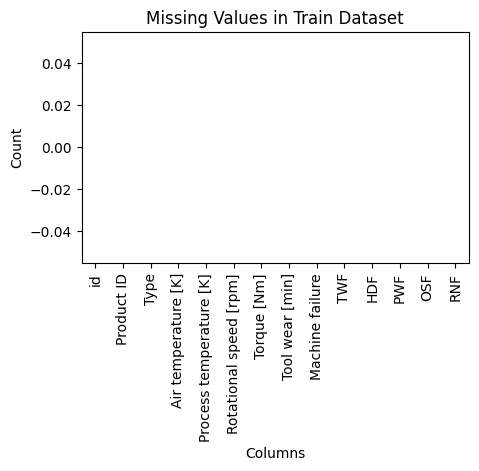

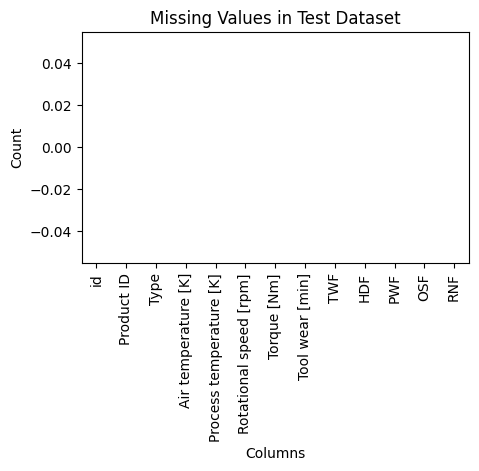

In [13]:
# Visualizing the missing values

# Missing values
train_missing = train.isnull().sum()
test_missing = test.isnull().sum()

# Train dataset
plt.figure(figsize=(5,3))
train_missing.plot(kind='bar', color='orange')
plt.title("Missing Values in Train Dataset")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

# Test dataset
plt.figure(figsize=(5,3))
test_missing.plot(kind='bar', color='orange')
plt.title("Missing Values in Test Dataset")
plt.xlabel("Columns")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

### What did you know about your dataset?

After loading and inspecting the train and test datasets, the following observations were made.

**Dataset Overview**
| Dataset       | Rows    | Columns |
| ------------- | ------- | ------- |
| Train Dataset | 136,429 | 14      |
| Test Dataset  | 90,954  | 13      |

---

**Key Observations**

*  The train dataset contains the target variable Machine failure, while the test dataset does not contain this column.

*  Both datasets contain machine operational parameters such as temperature, rotational speed, torque, and tool wear.

*  The dataset also includes specific failure type indicators such as:

    *  TWF (Tool Wear Failure)

    *  HDF (Heat Dissipation Failure)

    *  PWF (Power Failure)

    *  OSF (Overstrain Failure)

    *  RNF (Random Failure)

---

**Data Quality**

*  **Missing Values:** No missing values were found in either dataset.

*  **Duplicate Records:** No duplicate rows were present in both datasets.

*  **Data Types:**

    *  Numerical features include temperature, speed, torque, and tool wear.

    *  Categorical features include Product ID and Type.

---

**Column Structure**

| Category           | Columns                                                                   |
| ------------------ | ------------------------------------------------------------------------- |
| Identifier Columns | id, Product ID                                                            |
| Machine Parameters | Air temperature, Process temperature, Rotational speed, Torque, Tool wear |
| Failure Indicators | TWF, HDF, PWF, OSF, RNF                                                   |
| Target Variable    | Machine failure (only in train dataset)                                   |

---

**Initial Understanding**

*  The dataset is structured for a binary classification problem, where the goal is to predict whether a machine will fail or not.

*  The machine condition variables will likely play an important role in determining failure patterns.

## ***2. Understanding Your Variables***

In [14]:
# Dataset Columns

#train dataset
train.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

In [15]:
#test dataset
test.columns

Index(['id', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [16]:
# Dataset Describe
train.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000,136429.000000
mean,68214.000000,299.862776,309.941070,1520.331110,40.348643,104.408901,0.015744,0.001554,0.005160,0.002397,0.003958,0.002258
std,39383.804275,1.862247,1.385173,138.736632,8.502229,63.965040,0.124486,0.039389,0.071649,0.048899,0.062789,0.047461
min,0.000000,295.300000,305.800000,1181.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,34107.000000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,68214.000000,300.000000,310.000000,1493.000000,40.400000,106.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,102321.000000,301.200000,310.900000,1580.000000,46.100000,159.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,136428.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [17]:
test.describe()

,id,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,RNF
count,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.000000,90954.00000,90954.000000
mean,181905.500000,299.859493,309.939375,1520.528179,40.335191,104.293962,0.001473,0.005343,0.002353,0.00387,0.002309
std,26256.302529,1.857562,1.385296,139.970419,8.504683,63.871092,0.038355,0.072903,0.048449,0.06209,0.047995
min,136429.000000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000
25%,159167.250000,298.300000,308.700000,1432.000000,34.600000,48.000000,0.000000,0.000000,0.000000,0.00000,0.000000
50%,181905.500000,300.000000,310.000000,1493.000000,40.500000,106.000000,0.000000,0.000000,0.000000,0.00000,0.000000
75%,204643.750000,301.200000,310.900000,1579.000000,46.200000,158.000000,0.000000,0.000000,0.000000,0.00000,0.000000
max,227382.000000,304.400000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.00000,1.000000


### Variables Description

| Variable                | Description                                                                               |
| ----------------------- | ----------------------------------------------------------------------------------------- |
| id                      | Unique identifier for each record                                                         |
| Product ID              | Unique identifier assigned to each product                                                |
| Type                    | Type/category of the product (e.g., L, M, H)                                              |
| Air temperature [K]     | Temperature of the surrounding air measured in Kelvin                                     |
| Process temperature [K] | Temperature of the machine process in Kelvin                                              |
| Rotational speed [rpm]  | Speed at which the machine is rotating                                                    |
| Torque [Nm]             | Amount of rotational force applied by the machine                                         |
| Tool wear [min]         | Duration of tool usage measured in minutes                                                |
| Machine failure         | Target variable indicating whether machine failure occurred (1 = failure, 0 = no failure) |
| TWF                     | Tool Wear Failure indicator                                                               |
| HDF                     | Heat Dissipation Failure indicator                                                        |
| PWF                     | Power Failure indicator                                                                   |
| OSF                     | Overstrain Failure indicator                                                              |
| RNF                     | Random Failure indicator                                                                  |


### Check Unique Values for each variable.

In [18]:
# Check Unique Values for each variable.
train.nunique()

,0
id,136429
Product ID,9976
Type,3
Air temperature [K],95
Process temperature [K],81
Rotational speed [rpm],952
Torque [Nm],611
Tool wear [min],246
Machine failure,2
TWF,2


In [19]:
test.nunique()

,0
id,90954
Product ID,9909
Type,3
Air temperature [K],92
Process temperature [K],84
Rotational speed [rpm],946
Torque [Nm],595
Tool wear [min],246
TWF,2
HDF,2


## 3. ***Data Wrangling***

### Data Wrangling Code

**1. Remove identifier columns**

In [20]:
# drop identifier columns
train = train.drop(columns=['id', 'Product ID'])
test = test.drop(columns=['id', 'Product ID'])

# check columns
train.columns
test.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

**Check**

In [21]:
# check columns
train.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
       'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

In [22]:
test.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF'],
      dtype='object')

**2. Check categorical column values**

In [23]:
train['Type'].value_counts()

,count
Type,
L,95354
M,32152
H,8923


In [24]:
test['Type'].value_counts()

,count
Type,
L,63438
M,21535
H,5981


**Verify binary failure columns**

In [25]:
failure_cols = ['Machine failure','TWF','HDF','PWF','OSF','RNF']

for col in failure_cols:
    print(col, train[col].unique())

Machine failure [0 1]
TWF [0 1]
HDF [0 1]
PWF [0 1]
OSF [0 1]
RNF [0 1]


In [26]:
failure_cols_test = ['TWF','HDF','PWF','OSF','RNF']

for col in failure_cols_test:
    print(col, test[col].unique())

TWF [0 1]
HDF [0 1]
PWF [0 1]
OSF [0 1]
RNF [0 1]


**Check data types consistency**

In [27]:
train.dtypes

,0
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
Machine failure,int64
TWF,int64
HDF,int64
PWF,int64


In [28]:
test.dtypes

,0
Type,object
Air temperature [K],float64
Process temperature [K],float64
Rotational speed [rpm],int64
Torque [Nm],float64
Tool wear [min],int64
TWF,int64
HDF,int64
PWF,int64
OSF,int64


**Rename columns (remove spaces and units)**

In [29]:
train = train.rename(columns={
    'Air temperature [K]':'air_temperature',
    'Process temperature [K]':'process_temperature',
    'Rotational speed [rpm]':'rotational_speed',
    'Torque [Nm]':'torque',
    'Tool wear [min]':'tool_wear',
    'Machine failure':'machine_failure'
})

test = test.rename(columns={
    'Air temperature [K]':'air_temperature',
    'Process temperature [K]':'process_temperature',
    'Rotational speed [rpm]':'rotational_speed',
    'Torque [Nm]':'torque',
    'Tool wear [min]':'tool_wear'
})

train.columns

Index(['Type', 'air_temperature', 'process_temperature', 'rotational_speed',
       'torque', 'tool_wear', 'machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

**Check class distribution of target variable**

In [30]:
train['machine_failure'].value_counts()

,count
machine_failure,
0,134281
1,2148


**Convert Type column to categorical**

In [31]:
train['Type'] = train['Type'].astype('category')
test['Type'] = test['Type'].astype('category')

train.dtypes

,0
Type,category
air_temperature,float64
process_temperature,float64
rotational_speed,int64
torque,float64
tool_wear,int64
machine_failure,int64
TWF,int64
HDF,int64
PWF,int64


**Recheck dataset shape and columns**

In [32]:
# Dataset Rows & Columns count

print(f"The train data has {train.shape[0]} rows and {train.shape[1]} columns")
print(f"The test data has {test.shape[0]} rows and {test.shape[1]} columns")


The train data has 136429 rows and 12 columns
The test data has 90954 rows and 11 columns


In [33]:
train.columns

Index(['Type', 'air_temperature', 'process_temperature', 'rotational_speed',
       'torque', 'tool_wear', 'machine_failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='object')

### What all manipulations have you done and insights you found?

**Data Manipulations Performed**

*  Removed identifier columns

    *  Dropped id and Product ID since they only act as record identifiers and do not contribute to machine failure prediction.

*  Checked missing values

    *  Verified that both train and test datasets contain no missing values.

*  Checked duplicate records

    *  Confirmed that no duplicate rows exist in either dataset.

*  Verified categorical feature

    *  Inspected the Type column and found three categories (L, M, H) representing different product types.

*  Validated binary columns

    *  Confirmed that machine_failure, TWF, HDF, PWF, OSF, and RNF contain binary values (0 and 1).

*  Checked data types

    *  Ensured numerical variables (temperature, speed, torque, tool wear) are stored as numeric types and categorical variables as object/category.

*  Renamed columns

    *  Cleaned column names by removing spaces and units to make them easier to use during analysis and modeling.

*  Converted categorical data type

    *  Converted the Type column to categorical format for better memory efficiency and easier encoding later.

---

**Key Insights from Data Wrangling**

*  The dataset is clean and well-structured with no missing or duplicate values.

*  The target variable (machine_failure) is binary, making this a binary classification problem.

*  The dataset is highly imbalanced, with far fewer failure cases compared to non-failure cases.

*  Product type distribution is similar in both train and test datasets, indicating consistent data structure.

*  The train and test datasets have almost identical features, except for the target column present only in the training dataset.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### **UNIVARIATE ANALYSIS**

#### **Chart - 1 Distribution of Numerical Features**

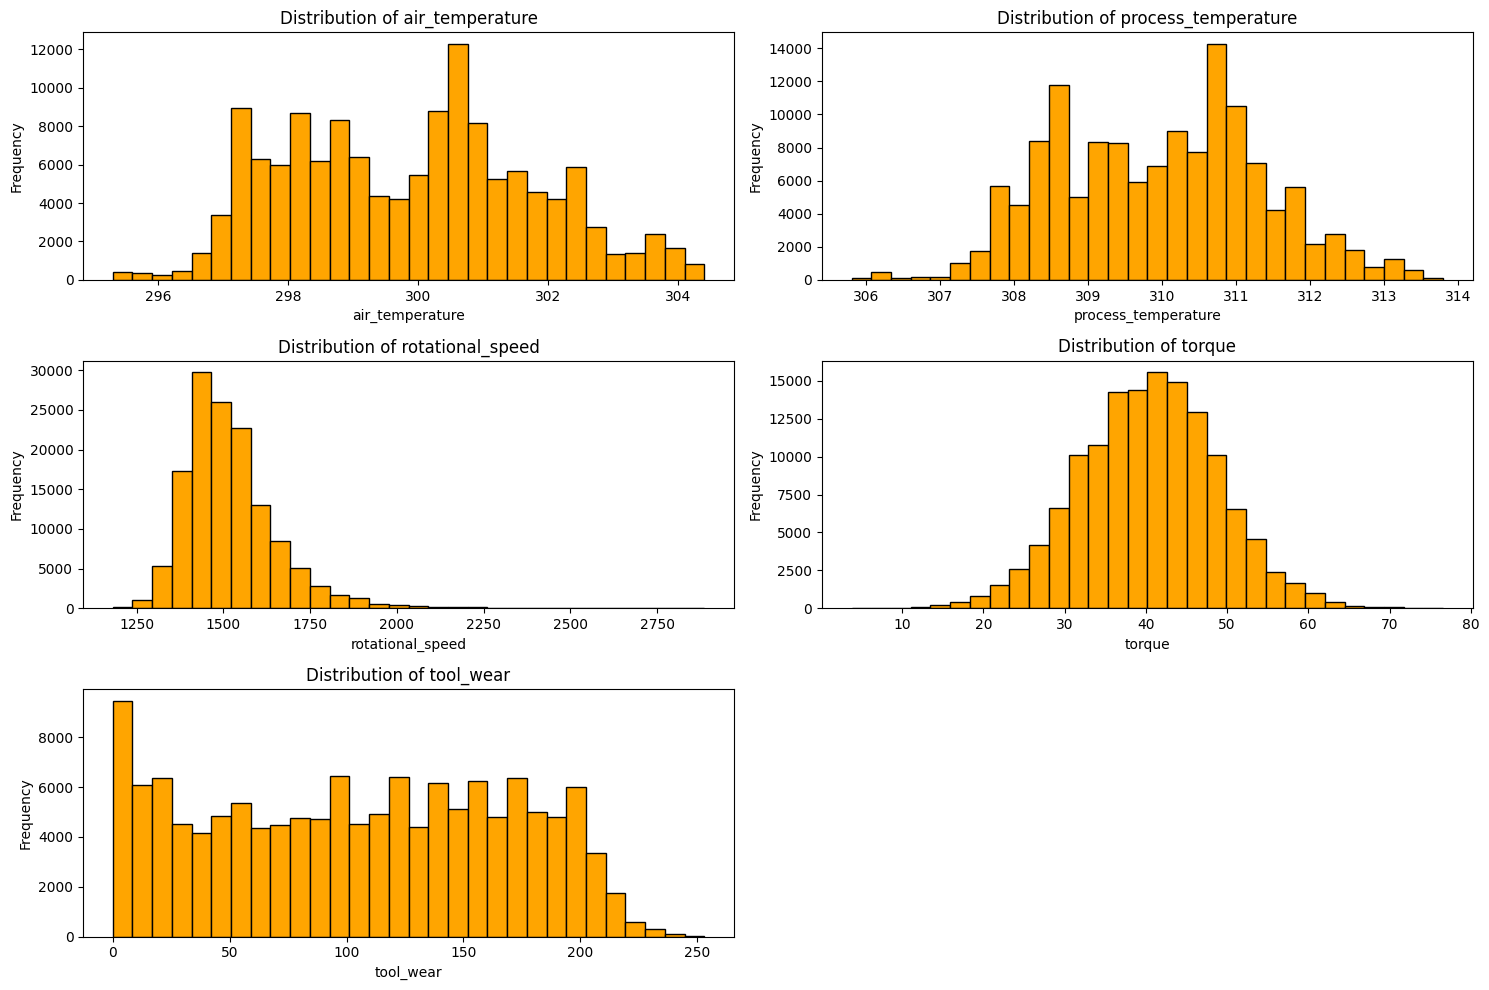

In [34]:
# Chart - 1 visualization code

# List of numerical columns
num_cols = [
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear'
]

# Create histograms for each numerical feature
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)

    # Histogram plot
    plt.hist(train[col], bins=30, color='orange', edgecolor='black')

    # Titles and labels
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  To understand distribution of numerical features.

*  Helps identify skewness, spread, and potential outliers.

*  Important for deciding scaling, transformation, or model suitability.

##### 2. What is/are the insight(s) found from the chart?

*  Air temperature and process temperature

    *  Roughly normally distributed with small variation.

    *  Indicates stable operating environment.

*  Rotational speed

    *  Slight right skew.

    *  Most machines operate between 1400–1700 rpm.

*  Torque

    *  Approximately normal distribution centered around ~40 Nm.

*  Tool wear

    *  Spread across a wide range 0–250 minutes.

    *  Indicates tools operate across various lifecycle stages.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*  Stable temperature distributions suggest controlled production environment, reducing risk of thermal-related failures.

*  Identifying common ranges for speed and torque helps define safe operational thresholds.

**Potential Negative Insight**

*  Wide distribution in tool wear may indicate inconsistent maintenance schedules, which could increase the probability of machine failures if not monitored properly.

#### **Chart - 2 Target Variable Distribution (machine_failure)**

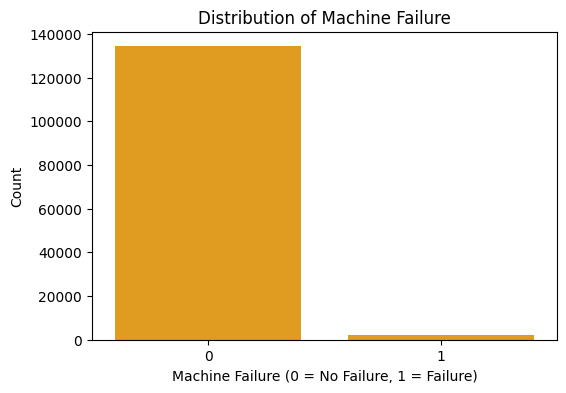

In [35]:
# Chart - 2 visualization code

# Create figure
plt.figure(figsize=(6,4))

# Countplot of target variable
sns.countplot(
    x='machine_failure',
    data=train,
    color='orange'
)

# Titles and labels
plt.title('Distribution of Machine Failure')
plt.xlabel('Machine Failure (0 = No Failure, 1 = Failure)')
plt.ylabel('Count')

plt.show()

##### 1. Why did you pick the specific chart?

*  To understand the distribution of the target variable.

*  Helps detect class imbalance, which can strongly affect model performance.

##### 2. What is/are the insight(s) found from the chart?

*  The dataset is heavily imbalanced.

    *  Non-failure cases (0) dominate the dataset.

    *  Failure cases (1) are very rare compared to normal machine operations.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*  The low number of failures suggests that machines generally operate reliably, which is good for production stability.

**Negative Insight**

*  Severe class imbalance may cause ML models to bias toward predicting non-failure, reducing the model's ability to detect real failures.

*  If not handled properly, this could lead to missed failure predictions, increasing downtime and maintenance costs.

#### **Chart - 3 Product Type Distribution (Type)**

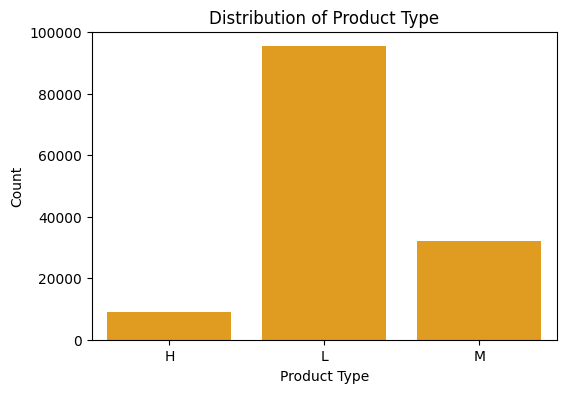

In [36]:
# Chart - 3 visualization code

# Create figure
plt.figure(figsize=(6,4))

# Countplot for product type
sns.countplot(
    x='Type',
    data=train,
    color='orange'
)

# Titles and labels
plt.title('Distribution of Product Type')
plt.xlabel('Product Type')
plt.ylabel('Count')

plt.show()

##### 1. Why did you pick the specific chart?

*  To understand the distribution of the categorical variable Type.

*  Helps identify whether some product types dominate the dataset.

##### 2. What is/are the insight(s) found from the chart?

*  L type products are the most common in the dataset.

*  M type products appear in moderate numbers.

*  H type products are relatively rare.

The dataset is not evenly distributed across product categories.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*  Understanding product type distribution helps in analyzing whether certain product categories contribute more to machine stress or failure.

**Potential Negative Insight**

*  Since L type dominates the dataset, models might learn patterns more strongly from this category, which could bias predictions toward L-type machine behavior.

### **BIVARIATE ANALYSIS**

#### **NUMERICAL VS TARGET**

#### **Chart - 4 Numerical Features vs Target (machine_failure)**

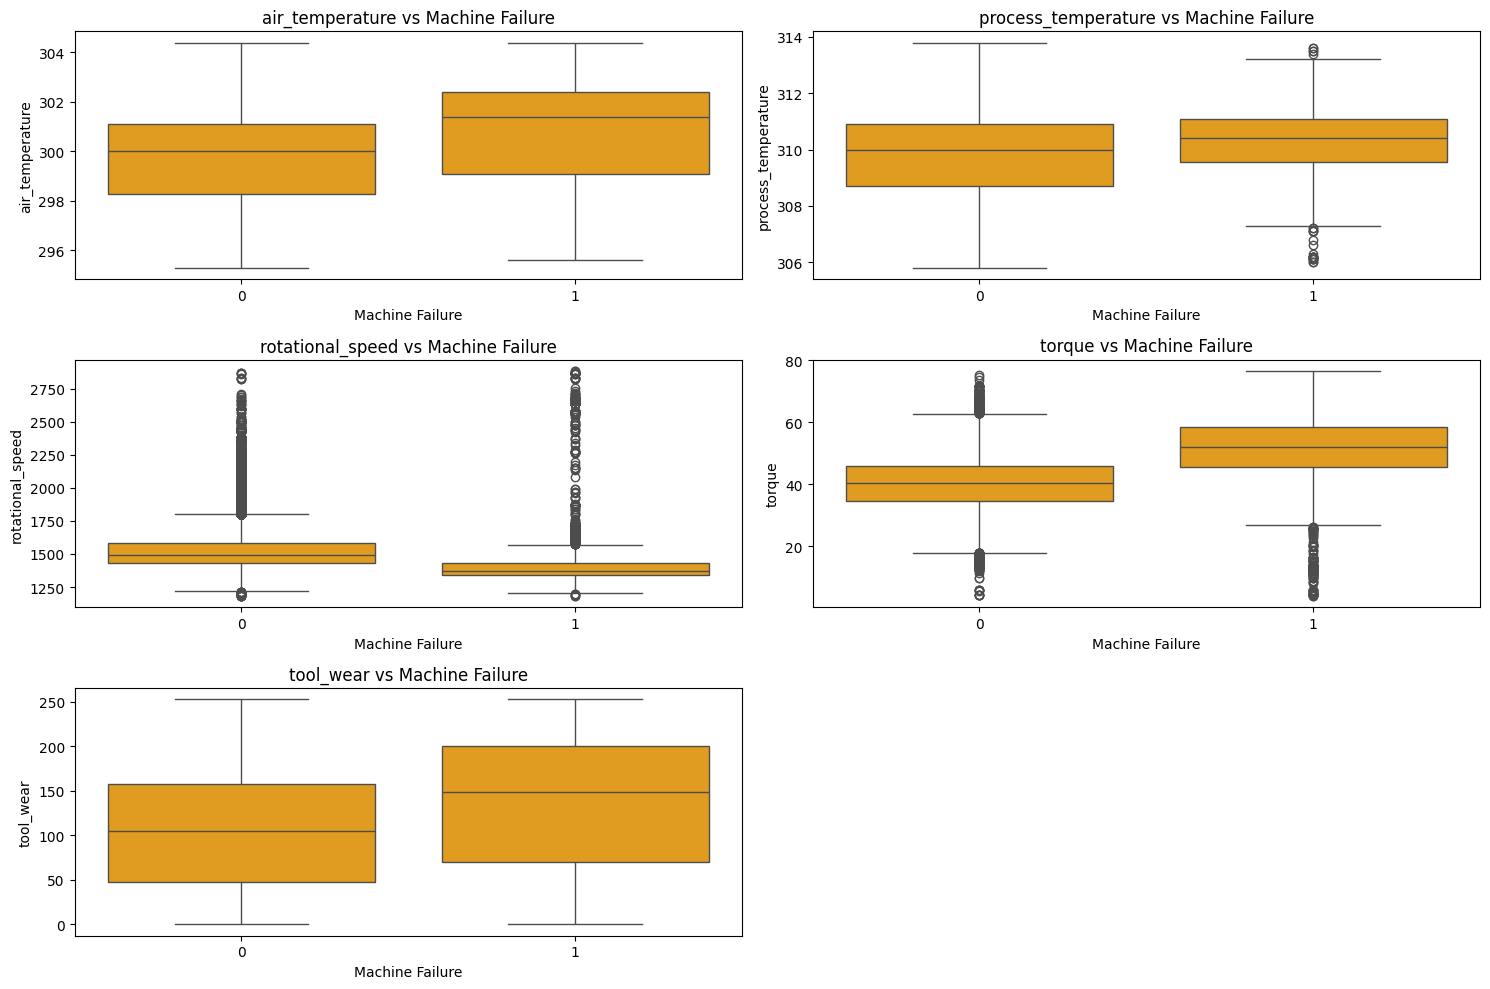

In [37]:
# Chart - 4 visualization code

# Numerical columns
num_cols = [
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear'
]

# Create boxplots
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols, 1):
    plt.subplot(3,2,i)

    sns.boxplot(
        x='machine_failure',
        y=col,
        data=train,
        color='orange'
    )

    plt.title(f'{col} vs Machine Failure')
    plt.xlabel('Machine Failure')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

##### 1. Why did you pick the specific chart?

*  Boxplots help compare distributions of numerical variables across target classes.

*  Useful to detect differences in median, spread, and outliers between failure and non-failure machines.

##### 2. What is/are the insight(s) found from the chart?

*  Air temperature & Process temperature

    *  Failure cases show slightly higher median temperatures.

*  Rotational speed

    *  Failure cases tend to occur at lower rotational speeds.

*  Torque

    *  Failure cases have higher torque values compared to normal machines.

*  Tool wear

    *  Machines with higher tool wear show more failure cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*  Helps identify operational conditions that increase failure risk.

*  Maintenance teams can monitor torque levels and tool wear to prevent breakdowns.

**Negative Insight**

*  High tool wear and torque indicate machines may be operating beyond optimal limits, which can increase failure probability and lead to production downtime.

#### **CATEGORICAL VS TARGET**

#### **Chart - 5 Product Type vs Machine Failure**

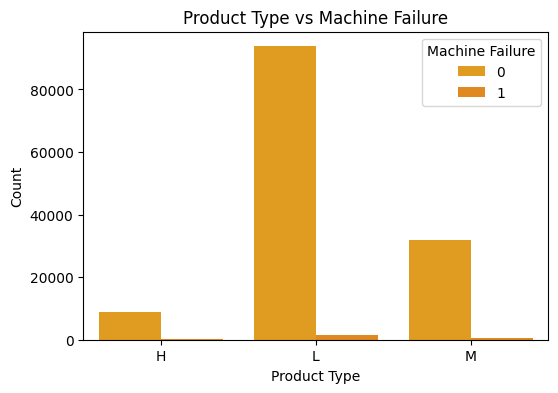

In [38]:
# Chart - 5 visualization code

# Create figure
plt.figure(figsize=(6,4))

# Countplot with hue to compare failure across product types
sns.countplot(
    x='Type',
    hue='machine_failure',
    data=train,
    palette=['orange','darkorange']
)

# Titles and labels
plt.title('Product Type vs Machine Failure')
plt.xlabel('Product Type')
plt.ylabel('Count')

plt.legend(title='Machine Failure')
plt.show()

##### 1. Why did you pick the specific chart?

*  To examine whether machine failures vary across different product types (L, M, H).

*  Helps check if product category influences failure probability.

##### 2. What is/are the insight(s) found from the chart?

*  L type products dominate the dataset, so most failures appear in this category.

*  M type products show moderate presence and some failures.

*  H type products appear least frequently, with very few failure cases.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*  Helps understand whether specific product categories place more stress on machines.

**Negative Insight**

*  The dominance of L type products may make it harder to determine if failures are truly linked to product type or simply due to data imbalance.

### **MULTIVARIATE ANALYSIS**

#### **Chart - 6 Correlation Heatmap**

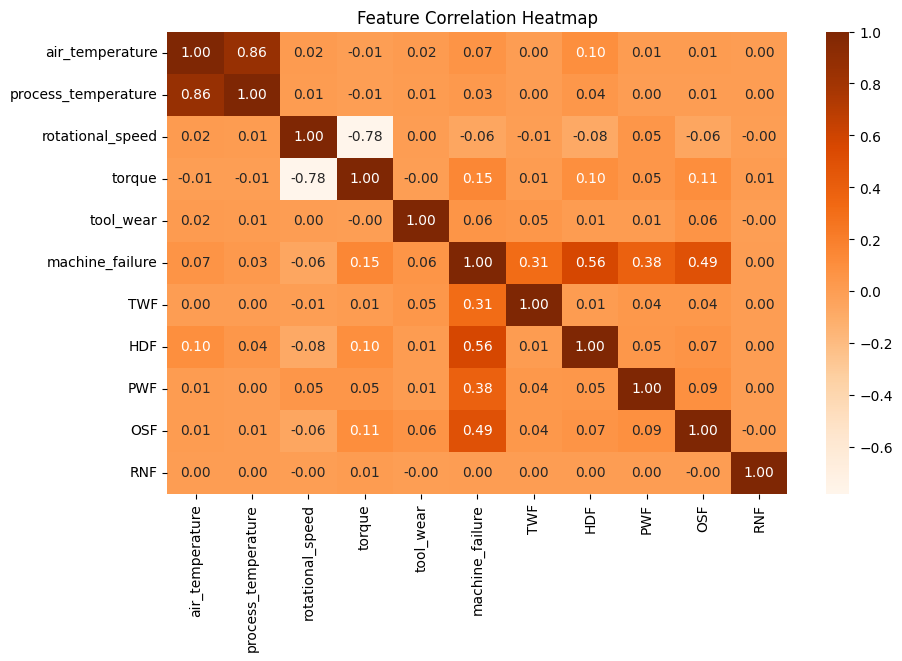

In [39]:
# Chart - 6 visualization code

# Select only numerical columns
corr = train.select_dtypes(include=['int64','float64']).corr()

# Create heatmap
plt.figure(figsize=(10,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='Oranges',
    fmt=".2f"
)

# Titles
plt.title("Feature Correlation Heatmap")

plt.show()

##### 1. Why did you pick the specific chart?

*  A heatmap helps visualize correlation between multiple numerical variables simultaneously.

*  Useful to identify strong relationships between features and the target variable.

##### 2. What is/are the insight(s) found from the chart?

*  Air temperature and process temperature show a strong positive correlation (~0.86).

*  Rotational speed and torque have a strong negative correlation (~ -0.78).

*  Machine failure shows noticeable correlation with:

    *  HDF (~0.56)

    *  OSF (~0.49)

    *  PWF (~0.38)

    *  TWF (~0.31)

*  Random failure (RNF) has almost no correlation with other variables.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*  Identifying correlations with failure indicators helps detect early warning signals of machine breakdown.

*  Maintenance teams can monitor heat dissipation and overstrain conditions to reduce failures.

**Negative Insight**

*  High correlation between air temperature and process temperature may introduce redundancy, which can reduce model interpretability if both are used without consideration.

#### **Chart - 7 Pairplot (Key Numerical Features)**

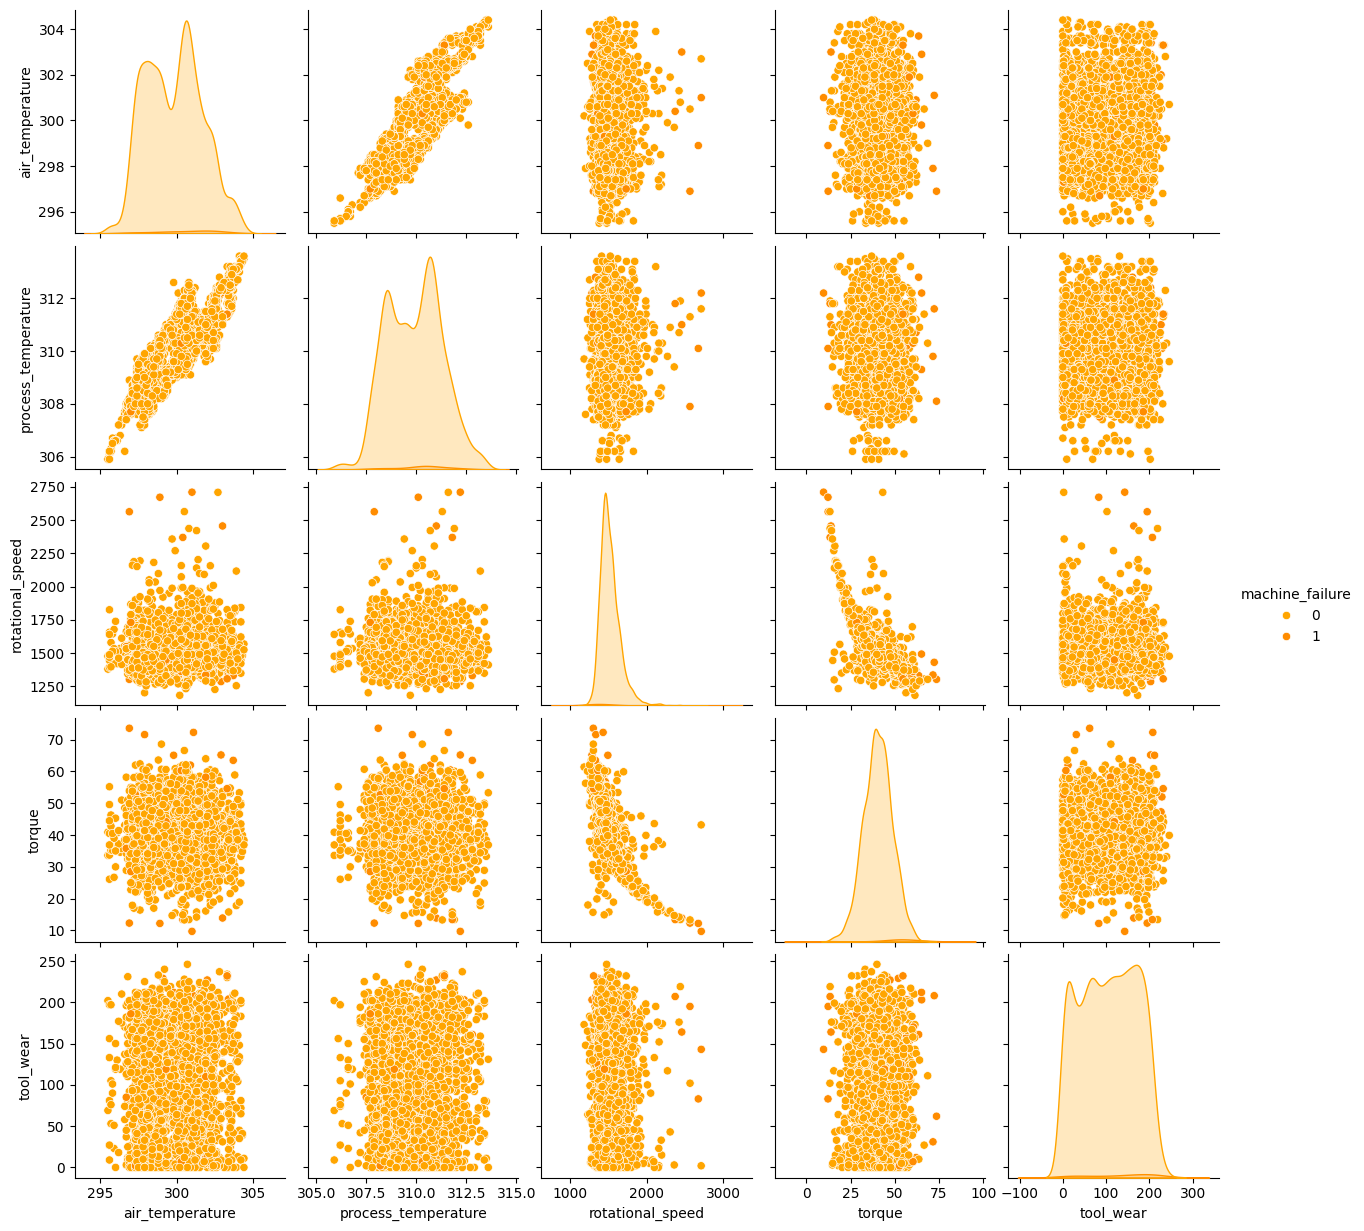

In [43]:
# Chart - 7 visualization code

# Take a sample of data
sample_data = train.sample(3000, random_state=42)

pairplot_cols = [
    'air_temperature',
    'process_temperature',
    'rotational_speed',
    'torque',
    'tool_wear',
    'machine_failure'
]

sns.pairplot(
    sample_data[pairplot_cols],
    hue='machine_failure',
    palette=['orange','darkorange']
)

plt.show()

##### 1. Why did you pick the specific chart?

*  Pairplot helps visualize relationships between multiple numerical features simultaneously.

*  It allows quick detection of clusters, correlations, and separability between failure and non-failure cases.

In [41]:
print("hello")

hello


##### 2. What is/are the insight(s) found from the chart?

*  Air temperature and process temperature show a strong linear relationship.

*  Rotational speed and torque show a clear inverse relationship.

*  Failure cases overlap heavily with non-failure cases, indicating no single variable alone explains machine failure.

*  Machine failure likely depends on combined effect of multiple parameters.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact**

*  Confirms that multiple operational factors together influence machine failures, supporting the use of machine learning models instead of simple threshold rules.

**Negative Insight**

*  Since failure points overlap with normal operations, detecting failures using simple monitoring rules could be difficult, which may lead to missed early warning signals without predictive analytics.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

Answer Here.

#### 2. Perform an appropriate statistical test.

In [ ]:
# Perform Statistical Test to obtain P-Value

##### Which statistical test have you done to obtain P-Value?

Answer Here.

##### Why did you choose the specific statistical test?

Answer Here.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [ ]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [ ]:
# Handling Outliers & Outlier treatments

##### What all outlier treatment techniques have you used and why did you use those techniques?

Answer Here.

### 3. Categorical Encoding

In [ ]:
# Encode your categorical columns

#### What all categorical encoding techniques have you used & why did you use those techniques?

Answer Here.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [ ]:
# Expand Contraction

#### 2. Lower Casing

In [ ]:
# Lower Casing

#### 3. Removing Punctuations

In [ ]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [ ]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [ ]:
# Remove Stopwords

In [ ]:
# Remove White spaces

#### 6. Rephrase Text

In [ ]:
# Rephrase Text

#### 7. Tokenization

In [ ]:
# Tokenization

#### 8. Text Normalization

In [ ]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [ ]:
# POS Taging

#### 10. Text Vectorization

In [ ]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 4. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [ ]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [ ]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 5. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [ ]:
# Transform Your data

### 6. Data Scaling

In [ ]:
# Scaling your data

##### Which method have you used to scale you data and why?

### 7. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [ ]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 8. Data Splitting

In [ ]:
# Split your data to train and test. Choose Splitting ratio wisely.

##### What data splitting ratio have you used and why?

Answer Here.

### 9. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [ ]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [ ]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

Answer Here.

### ML Model - 3

In [ ]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

In [ ]:
# Visualizing evaluation Metric Score chart

#### 2. Cross- Validation & Hyperparameter Tuning

In [ ]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

##### Which hyperparameter optimization technique have you used and why?

Answer Here.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Answer Here.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

Answer Here.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

Answer Here.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

Answer Here.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [ ]:
# Save the File

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [ ]:
# Load the File and predict unseen data.

### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***